# PRF fitting with prfpy
This is a walk through of how you can do fitting with prfpy. It is essentially the same as ```s01_gauss_prfpy.py``` - but you can go through step by step to see how it all works. 

In [1]:
# Import relevant tools
# - select "prf" conda environment for your kernel
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt

from prfpy.stimulus import PRFStimulus2D
from prfpy.model import Iso2DGaussianModel
from prfpy.fit import Iso2DGaussianFitter
from prfpy.rf import gauss2D_iso_cart

import os
opj = os.path.join
import yaml
import pickle
from datetime import datetime

import glob
import re
import shutil
from pathlib import Path
import yaml

# Mesh plotting tools
from dpu_mini.mesh_maker import *

# Prfpy plotting tools 
from dpu_mini.plot_functions import *
from cvl_utils.prf_utils import *
from cvl_utils.prfpy_utils import *
from cvl_utils.prfpy_plotter import *

First we load the settings & model objects from the previous stage. Again you will need to change this to the appropriate paths



In [2]:
# First we need to load the settings
prf_settings = 'eg_prf_settings.yml'
with open(prf_settings) as f:
    prf_settings = yaml.safe_load(f)    


# Creating stimulus object


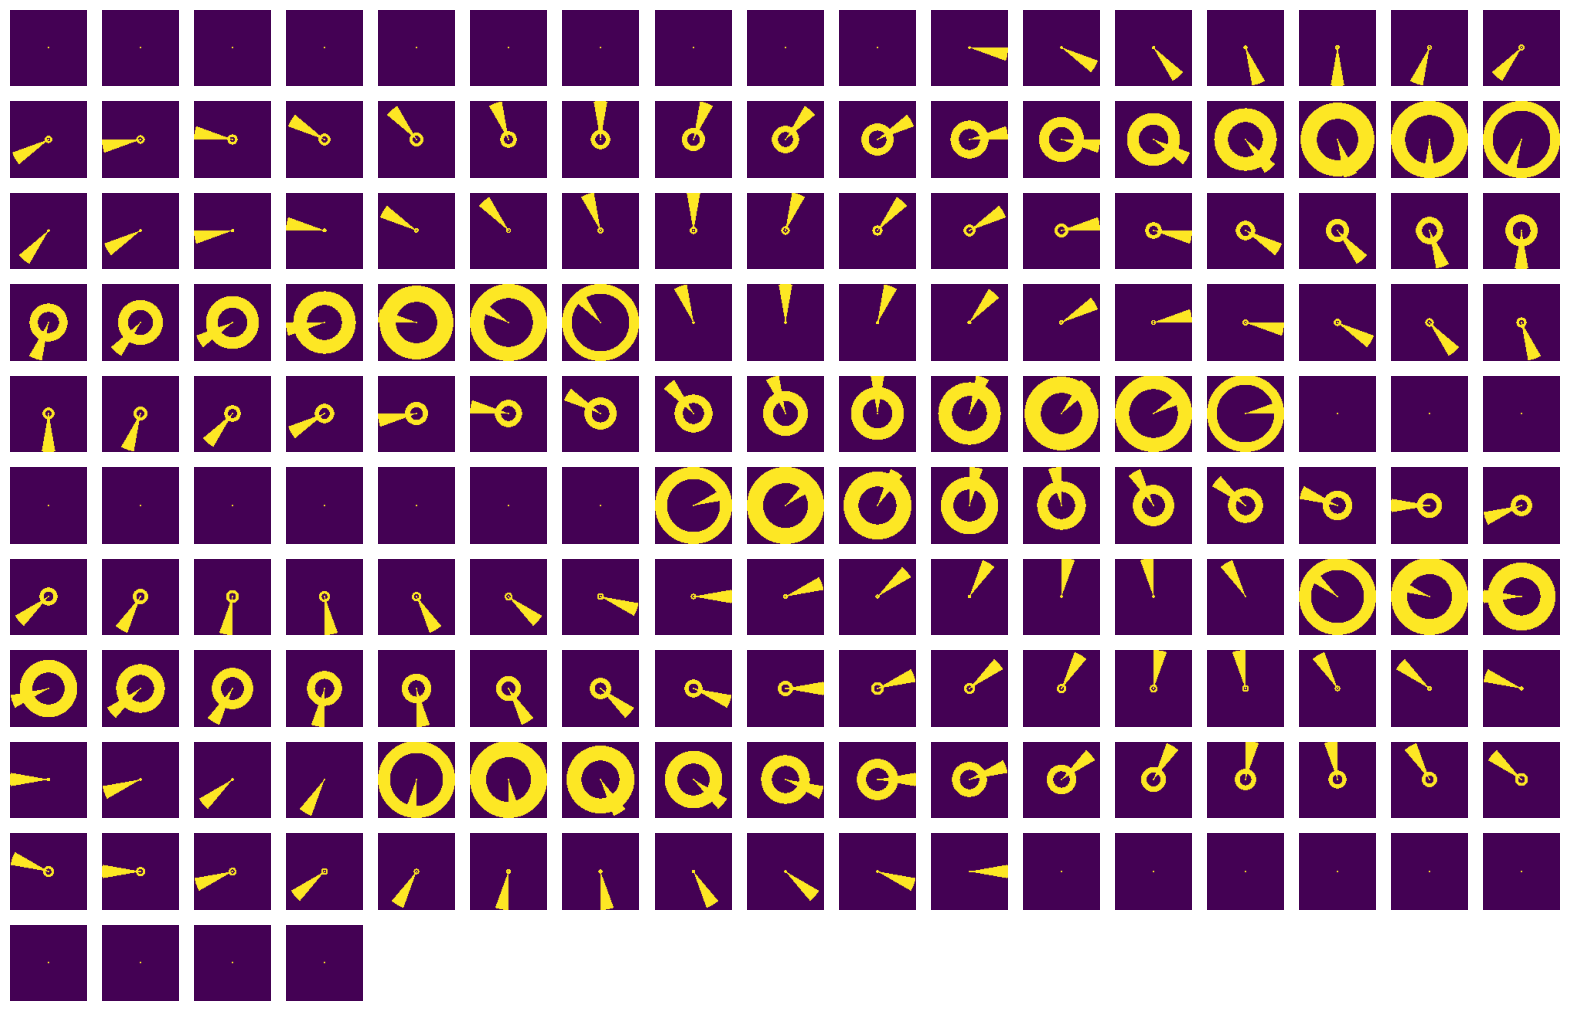

In [8]:
# If you already have the design matrix as a numpy array, you can simply load it...
# again you can change this to your dm
dm = np.load('eg_prf_dm.npy')

# You can see we have a binarized matrix, of a bar moving across the screen...
fig = plt.figure()
rows = 17
cols = 17
fig.set_size_inches(20,20)
for iax,idx in enumerate(range(1,348,2)):
    try:
        ax = fig.add_subplot(rows, cols, iax+1)
    except:
        print(idx)
    ax.imshow(dm[:,:,idx], vmin=0, vmax=1)
    ax.axis('off')


In [9]:
# Now we need to enter the design matrix in a way that prfpy can read it. 
# We do this using the PRFStimulus2D object
# Information we need
# -> Screen size (height), and distance (to the eye)
# This is so that we can convert into degrees of visual angle (dov)
# -> TR: This is so that we know the time (in s), of each 'frame' / pt in the time series
# Here we have 225 time points. So total length of scan was TR * 225 (1.5*225) 
prf_stim = PRFStimulus2D(
    screen_size_cm=prf_settings['screen_size_cm'],          # Distance of screen to eye
    screen_distance_cm=prf_settings['screen_distance_cm'],  # height of the screen (i.e., the diameter of the stimulated region)
    design_matrix=dm,                                   # dm (npix x npix x time_points)
    TR=prf_settings['TR'],                                  # TR
    )
print(f'Screen size in degrees of visual angle = {prf_stim.screen_size_degrees}')

# If for some reason you do not have the original dimensions, but you do have the dov, you can use this calculator:
# https://elvers.us/perception/visualAngle/ to make up some values for screen_size and distance, which will work...


Screen size in degrees of visual angle = 43.311978076844994


In [ ]:
prf_settings

{'TR': 1,
 'psc_baseline': 19,
 'vols_to_chop': 4,
 'n_jobs': 4,
 'n_batches': 10,
 'grid_nr': {'ecc': 10, 'pol': 10, 'size': 10, 'hrf_1': 1},
 'normalize_RFs': False,
 'fixed_grid_baseline': None,
 'bold_bsl': [-10, 10],
 'prf_ampl': [0, 1000],
 'rsq_threshold': 0.01,
 'hrf': {'pars': [1, 1, 0], 'deriv_bound': [0, 10], 'disp_bound': [0, 0]},
 'screen_size_cm': 27,
 'screen_distance_cm': 34,
 'eps': '1e-1',
 'filter_predictions': False,
 'norm': {'surround_amplitude_grid': [0.05, 0.2, 0.4, 0.7, 1, 3],
  'surround_size_grid': [5, 8, 12, 18],
  'neural_baseline_grid': [0, 1, 10, 100],
  'surround_baseline_grid': [0.1, 1.0, 10.0, 100.0],
  'surround_amplitude_bound': [0, 1000],
  'neural_baseline_bound': [0, 1000],
  'surround_baseline_bound': [1e-06, 1000]}}

# Loading data
Next we need to load the cortical surface data, and convert it from raw EPI signal across runs, to the mean percent signal change across runs. The following functions do this

In [71]:
# --- names & variables you will have to change ---
input_file = 's4_conf_sgw-347_po-3_d-0_pca6_OLD'
output_file = 's5_prf_testing'
subject = 'sub-hp01'
session = 'ses-01'
task = 'pRFLE'
roi = 'b14_V1.' # Just use the 
# ------ 


bids_dir = os.environ['BIDS_DIR']
fs_dir = opj(bids_dir, 'derivatives', 'freesurfer')
input_dir     = str(Path(
    opj(bids_dir, 'derivatives', input_file)
).resolve())
output_dir   = str(Path(
    opj(bids_dir, 'derivatives', output_file)
).resolve())

subject_input_dir    = opj(input_dir,     subject, session)
subject_output_dir   = opj(output_dir,   subject, session)

os.makedirs(subject_output_dir, exist_ok=True)

print('-' * 55)
print(' Surface data input  : {}'.format(input_dir))
print(' Output      : {}'.format(output_dir))
print(' Subject     : {}'.format(subject))
print(' Session     : {}'.format(session))
print(f' Settings    : {prf_settings}')
print('-' * 55)


-------------------------------------------------------
 Surface data input  : /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/240522NG/hypot/derivatives/s4_conf_sgw-347_po-3_d-0_pca6_OLD
 Output      : /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/240522NG/hypot/derivatives/s5_prf_testing
 Subject     : sub-hp01
 Session     : ses-01
 Settings    : {'TR': 1, 'psc_baseline': 19, 'vols_to_chop': 4, 'n_jobs': 4, 'n_batches': 10, 'grid_nr': {'ecc': 10, 'pol': 10, 'size': 10, 'hrf_1': 1}, 'normalize_RFs': False, 'fixed_grid_baseline': None, 'bold_bsl': [-10, 10], 'prf_ampl': [0, 1000], 'rsq_threshold': 0.01, 'hrf': {'pars': [1, 1, 0], 'deriv_bound': [0, 10], 'disp_bound': [0, 0]}, 'screen_size_cm': 27, 'screen_distance_cm': 34, 'eps': '1e-1', 'filter_predictions': False, 'norm': {'surround_amplitude_grid': [0.05, 0.2, 0.4, 0.7, 1, 3], 'surround_size_grid': [5, 8, 12, 18], 'neural_baseline_grid': [0, 1, 10, 100], 'surround_baseline_grid': [0.1, 1.0, 10.0, 100.0], 'surround_amplitude

In [72]:
from s01_gauss_prfpy import *
roi_mask = dpu_load_roi(subject, roi, fs_dir)
roi_idx = np.where(roi_mask)[0]
print(f'Loading roi {roi}, fitting {roi_mask.sum()} vertices')
print(f'(which is {roi_mask.mean()*100:.3f}% of all vertices)')
psc_file = opj(
    subject_input_dir, f'{subject}_{session}_task-{task}_avg-psc.npy')

psc_data = psc_average(
    subject_input_dir   = subject_input_dir,
    psc_file            = psc_file,
    task                = f'task-{task}',
    prf_settings        = prf_settings,
    )
print(f'Chopping data, removing first {prf_settings["vols_to_chop"]}')
psc_data=psc_data[roi_mask,prf_settings["vols_to_chop"]:]
# Check times series are correct shape as the design matrix
assert dm.shape[-1] == psc_data.shape[-1]


Loading roi b14_V1., fitting 7754 vertices
(which is 2.792% of all vertices)


FileNotFoundError: [Errno 2] No such file or directory: '/Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/240522NG/hypot/derivatives/s4_conf_sgw-347_po-3_d-0_pca6_OLD/sub-hp01/ses-01/sub-hp01_ses-01_task-pRFLE_avg-psc.npy'

# Creating the (gaussian) model
Next up we create the "gaussian" model object. ```prfpy``` is built with an "object oriented style" i.e., functions, settings and data are held together in one structure (rather than having multiple input-output functions)  

In [73]:
'''    
    """__init__ for Iso2DGaussianModel
    constructor, sets up stimulus and hrf for this Model
    Parameters
    ----------
    stimulus : PRFStimulus2D
        Stimulus object specifying the information about the stimulus,
        and the space in which it lives.
    hrf : string, list or numpy.ndarray, optional
        HRF shape for this Model.
        Can be 'direct', which implements nothing (for eCoG or later convolution),
        a list or array of 3, which are multiplied with the three spm HRF basis functions,
        and an array already sampled on the TR by the user.
        (the default is None, which implements standard spm HRF)
    filter_predictions : boolean, optional
        whether to high-pass filter the predictions, default False
    filter_type, filter_params : see timecourse.py
    normalize_RFs : whether or not to normalize the RF volumes (generally not needed).
'''
gmodel = Iso2DGaussianModel(
    stimulus=prf_stim,                                  # The stimulus we made earlier
    hrf=prf_settings['hrf']['pars'],                        # These are the parameters for the HRF that we normally use at Spinoza (with 7T data). (we can fit it, this will be done later...)
    filter_predictions = prf_settings['filter_predictions'],# Do you want to filter the predictions? (depends what you did to the data, try and match it... default is not to do anything)
    normalize_RFs= prf_settings['normalize_RFs'],           # Normalize the volume of the RF (so that RFs w/ different sizes have the same volume. Generally not needed, as this can be solved using the beta values i.e.,amplitude)
    )


A note on the HRF

Generally we only to fit "hrf_1" (i.e., the derivative). The HRF is created using the 3 SPM basis functions, and the 3 hrf parameters determine how this works. We tend to fix hrf_pars[0] to = 1, as parameter can confound with the size and the amplitude of the PRF estimate. Similarly we generally fix hrf_2 (the dispersion) to =0, because it can confound with inhibitory PRF models. It is possible to fix all the HRF parameters (i.e., and use the default) and still get good quality PRF fits.   


We also need to create the gaussian model fitter object

In [74]:
# Load the model fitter
gfit = Iso2DGaussianFitter(
    data=psc_data,                  # time series
    model=gmodel,                   # model (see above)
    n_jobs=prf_settings['n_jobs'],  # number of jobs to use in parallelization 
    )

NameError: name 'psc_data' is not defined

### Fitting 
Create a grid of possible prf models (different x,y, and size parameters) - and for each vertex, we find the best match. 

We also want to put some boundaries on possible values
We can set the baseline to 0  (```fixed_grid_baseline=0```) or let it have any value (```fixed_grid_baseline=None```)

In addition, there is the amplitude parameter (which scales the response). 

We want to put an upper limit for this too, so that we don't get strange responses

In [77]:

# keys for gauss pars
gaussp_keys = prfpy_params_dict()['gauss']
max_eccentricity = prf_stim.screen_size_degrees/2 # It doesn't make sense to look for PRFs which are outside the stimulated region
grid_nr = prf_settings['grid_nr'] # Size of the grid (i.e., number of possible PRF models). Higher number means that the grid fit will be more exact, but take longer...
eccs    = max_eccentricity * np.linspace(
    0.25, 1, grid_nr['ecc'])**2 # Squared because of cortical magnification, more efficiently tiles the visual field...
sizes   = max_eccentricity * np.linspace(
    0.1, 1, grid_nr['size'])**2  # Possible size values (i.e., sigma in gaussian model) 
polars  = np.linspace(
    0, 2*np.pi, grid_nr['pol'])              # Possible polar angle coordinates

# We can also fit the hrf in the same way (specifically the derivative)
# -> make a grid between 0-10 (see settings file)
if grid_nr['hrf_1'] == 1:
    # Stick to default hrf
    hrf_1_grid = np.array(prf_settings['hrf']['pars'][1])
else:
    hrf_1_grid = np.linspace(
        prf_settings['hrf']['deriv_bound'][0], 
        prf_settings['hrf']['deriv_bound'][1], 
        grid_nr['hrf_1'])
# We generally recommend to fix the dispersion value to 0
hrf_2_grid = np.array([0.0])
# Amplitude bounds for gauss grid fit - set [min, max]
gauss_grid_bounds = [[prf_settings['prf_ampl'][0],prf_settings['prf_ampl'][1]]] 
gauss_bounds = [
    (-1.5*max_eccentricity, 1.5*max_eccentricity),          # x bound
    (-1.5*max_eccentricity, 1.5*max_eccentricity),          # y bound
    (1e-1, max_eccentricity*3),                             # prf size bounds
    (prf_settings['prf_ampl'][0],prf_settings['prf_ampl'][1]),      # prf amplitude
    (prf_settings['bold_bsl'][0],prf_settings['bold_bsl'][1]),      # bold baseline (fixed)
    (prf_settings['hrf']['deriv_bound'][0], prf_settings['hrf']['deriv_bound'][1]), # hrf_1 bound
    (prf_settings['hrf']['disp_bound'][0], prf_settings['hrf']['disp_bound'][1]), # hrf_2 bound
]





In [111]:
# Run the grid fitting 
grid_csv = opj(
    subject_output_dir, 
    f'{subject}_{session}_roi-{roi}_task-{task}_model-gauss_stage-grid.csv')
gfit.grid_fit(
    ecc_grid=eccs,
    polar_grid=polars,
    size_grid=sizes,
    hrf_1_grid=hrf_1_grid,
    hrf_2_grid=hrf_2_grid,
    verbose=True,
    n_batches=prf_settings['n_batches'],               # The grid fit is performed in parallel over n_batches of units.Batch parallelization is faster than single-unit parallelization and of sequential computing.
    
    # Fix the bold baseline? 
    # Optional - generally set to None
    fixed_grid_baseline=prf_settings['fixed_grid_baseline'], 
    grid_bounds=gauss_grid_bounds
    )
# Sometimes the fits are bad and will return NaN values. We do not want this so will remove them here:
gfit.gridsearch_params = filter_for_nans(gfit.gridsearch_params)
gfit.gridsearch_r2 = filter_for_nans(gfit.gridsearch_r2)

grid_dict = {}
grid_dict['index'] = roi_idx
for key in gaussp_keys.keys():
    grid_dict[key] = gfit.gridsearch_params[:,gaussp_keys[key]]
grid_pd = pd.DataFrame(grid_dict)
grid_pars_np = gfit.gridsearch_params

grid_pd.to_csv(grid_csv)

Each batch contains approx. 776 voxels.


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 out of  10 | elapsed:    2.2s finished


## Gaussian Iterative Fit
Now we can do the iterative fit. This takes the best fitting grid (from the above stage), and iteratively tweaks the parameters until the best fit is founds. 

This takes a quite bit longer than the grid fit. We also need to setup the bounds for all the parameters. 

For me (Mac Air, M4) n-jobs=10; n-vertices=6630; 95 mins

It will be faster on the cluster

In [ ]:
# # OPTIONAL - THIS WILL TAKE A LONGER TIME... (depending on n-jobs & how good your pc is)
# iter_csv = opj(
#     subject_output_dir, 
#     f'{subject}_{session}_roi-{roi}_task-{task}_model-gauss_stage-iter.csv')
# gfit.iterative_fit(
#     rsq_threshold=0.1, #prf_settings['rsq_threshold'],    # Minimum variance explained. Puts a lower bound on the quality of PRF fits. Any fits worse than this are thrown away...     
#     verbose=True,
#     bounds=gauss_bounds,       # Bounds (on parameters)
#     )               
# # Sometimes the fits are bad and will return NaN values. We do not want this so will remove them here:
# gfit.iterative_search_params = filter_for_nans(gfit.iterative_search_params)

# iter_dict = {}
# iter_dict['index'] = roi_idx
# for key in gaussp_keys.keys():
#     iter_dict[key] = gfit.iterative_search_params[:,gaussp_keys[key]]
# iter_pd = pd.DataFrame(iter_dict)
# print(f'Mean r2 = {iter_pd["rsq"].mean():.3f}')
# iter_pd.to_csv(iter_csv) # save it as a csv file

# DONE!

To see how we can plot this, go to ```s02_prf_plotting.ipynb```

In [88]:
from cvl_utils.prfpy_plotter import *
from cvl_utils.prfpy_utils import *
po = TSPlotter(
    gf.iterative_search_params, 
    model='gauss', 
    prfpy_model=gg, 
    real_ts=data
)

prf_params.shape[-1]=8
include hrf = True
include rsq = True


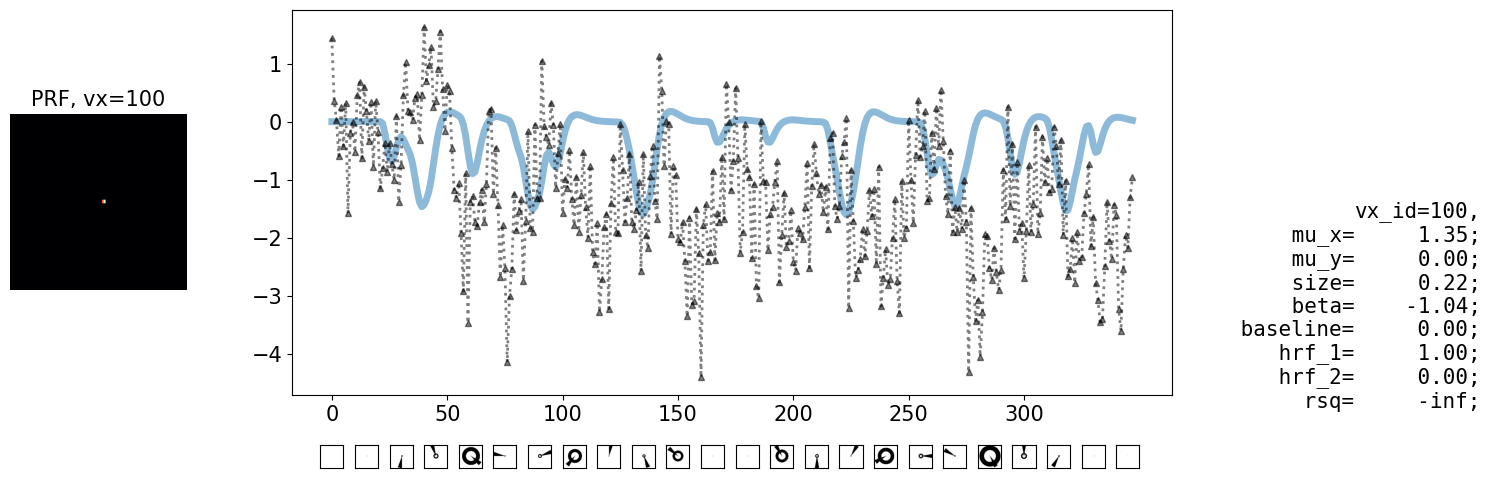

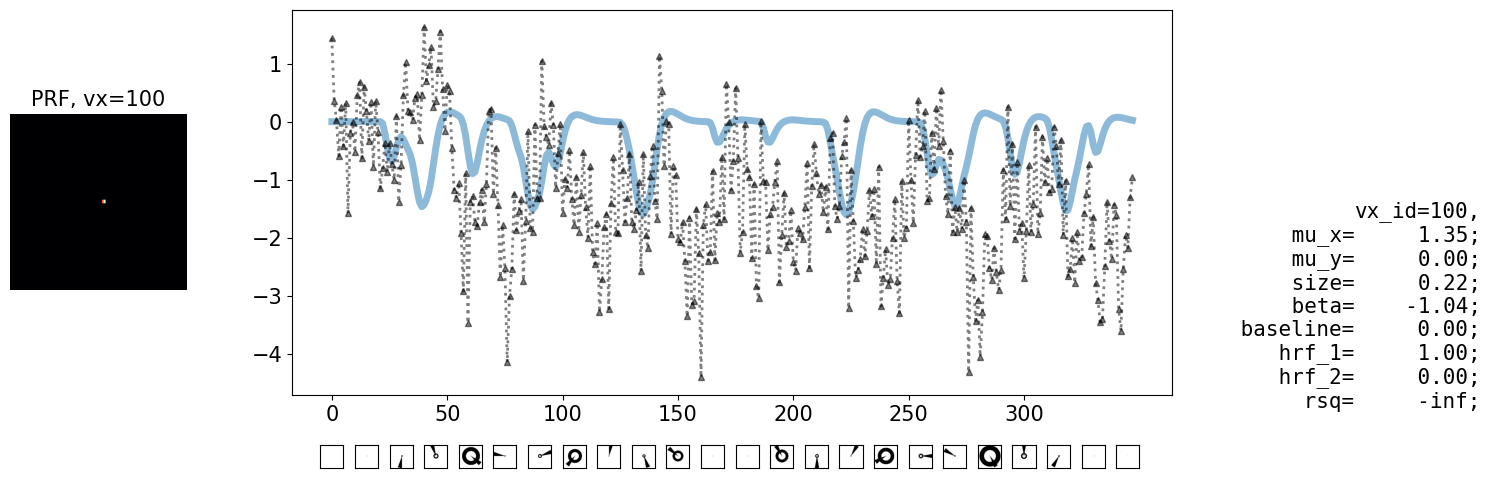

In [89]:
po.prf_ts_plot(100, do_dm=True)

In [ ]:
# fit_dir = opj(
#     os.environ['BIDS_DIR'], 'derivatives', 's5_prfpy', sub, ses
# )
# if not os.path.exists(fit_dir):
#     os.makedirs(fit_dir)
# giter_pkl = opj(fit_dir, 'giterB_pRFLE.pkl')
# # with open('wb', giter_pkl) as file:
# #     pickle.dump(gf.iterative_search_params, file)
# giter_np = opj(fit_dir, 'giter_pRFLE.npy')
# np.save(giter_np, gf.iterative_search_params)


[np.float64(-101.79127883294156), np.float64(0.0)]
[np.float64(-52.44168317346514), np.float64(54.94569262895441)]
[np.float64(-101.79127883294156), np.float64(107.55496455005256)]
[np.float64(-55.95763214545581), np.float64(57.071028830014015)]


{'cmap': 'RdBu', 'vmin': -20, 'vmax': 20}

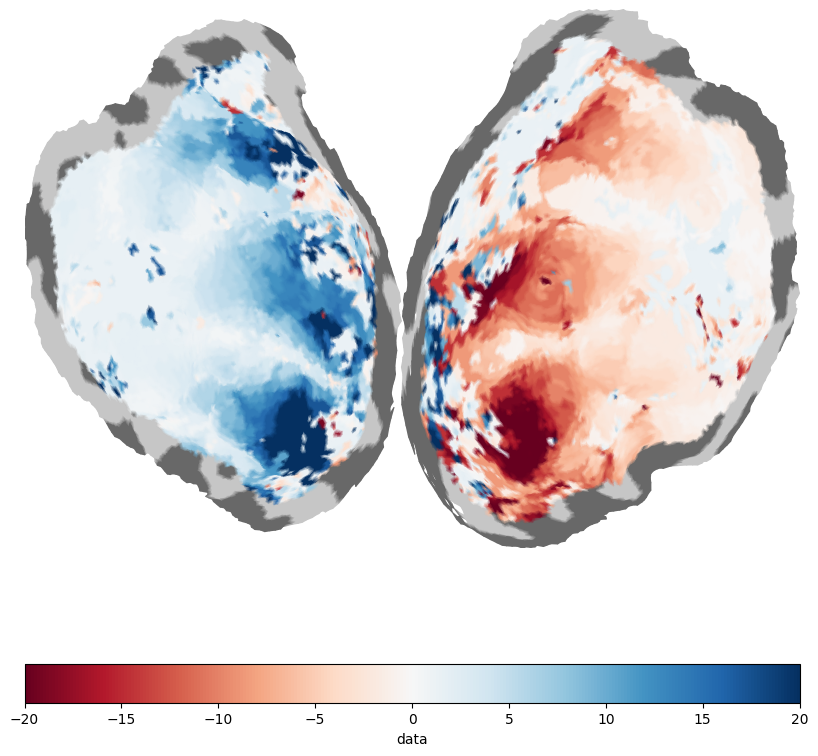

In [73]:
gm.flat_mpl(
    data=gf.iterative_search_params[:,0],
    data_sub_mask=tmask, 
    vmin=-20, vmax=20, cmap='RdBu', 
)

# WELL DONE!
We now have a set of prf fits. 


(-5.725064326420601, 5.725064326420601)

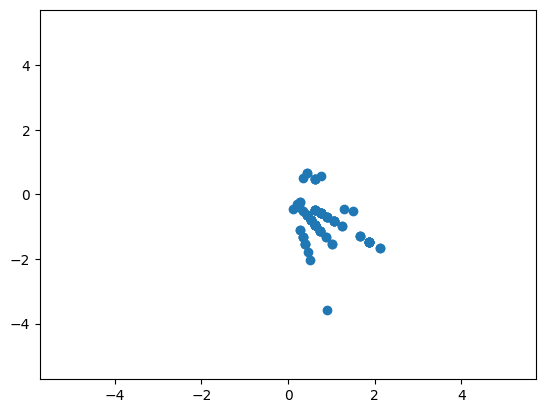

In [ ]:
# The parameters are stored as a np.ndarray with units x parameters
# gf.iterative_search_params[:,0] -> x position of prf
# gf.iterative_search_params[:,1] -> y position of prf
# gf.iterative_search_params[:,2] -> size of prf
# gf.iterative_search_params[:,3] -> amplitude of prf
# gf.iterative_search_params[:,4] -> baseline of prf
# gf.iterative_search_params[:,5] -> rsq of prf

g_idx = prfpy_params_dict()['gauss'] # this dictionary provides a look up table for the different gaussian parameters
# Plot the x,y location of all the PRFs, which have a good fit...
good_fit_idx = gf.iterative_search_params[:, g_idx['rsq']] > 0.1
good_fit_x = gf.iterative_search_params[good_fit_idx, g_idx['x']]
good_fit_y = gf.iterative_search_params[good_fit_idx, g_idx['y']]

plt.scatter(good_fit_x, good_fit_y)
plt.xlim(-max_eccentricity,max_eccentricity)
plt.ylim(-max_eccentricity,max_eccentricity)

In [29]:
# We can now create the predicted timeseries, and compare these with the data
prf_params = gf.iterative_search_params
pred_tc = gg.return_prediction(
    mu_x = prf_params[:,0], # x position
    mu_y = prf_params[:,1], # y position
    size = prf_params[:,2], # prf size
    beta = prf_params[:,3], # prf amplitude
    baseline = prf_params[:,4], # prf baseline (set to 0)
    hrf_1 = prf_params[:,5],
    hrf_2 = prf_params[:,6],
)

# Sometimes the fits are bad and will return NaN values. We do not want this so will remove them here:
pred_tc = filter_for_nans(pred_tc)

In [ ]:
# # Now to save everything in a nice convenient pickle file
# print('saving iterative search params')
# iter_file = './iter_fit.pkl'
# iter_dict = {}
# iter_dict['settings'] = prf_settings # Save the settings into the pickle file
# iter_dict['pars'] = gf.iterative_search_params # Save the parameters into the pickle file
# iter_dict['preds'] = pred_tc # Save the predicted time series into the pickle file
# iter_dict['date'] = datetime.now().strftime('%Y-%m-%d_%H-%M') # save the date into pickle
# f = open(iter_file, "wb")
# pickle.dump(iter_dict, f)
# f.close()


saving iterative search params


In [ ]:
# # To load this file all you need to do is:
# pkl_file = open(iter_file,'rb')
# loaded_iter_dict = pickle.load(pkl_file)
# pkl_file.close()     

# # Now you can access all the useful information together in one place


Have a look at the model fits:
* vary the voxel you are looking at (i_vx)
* also look at how the parameters (in the title), determine the location and size of the RF
* varying "time_pt", you can see where the stimulus is, at different times
* Note that the HRF means that responses of the model will be delayed...

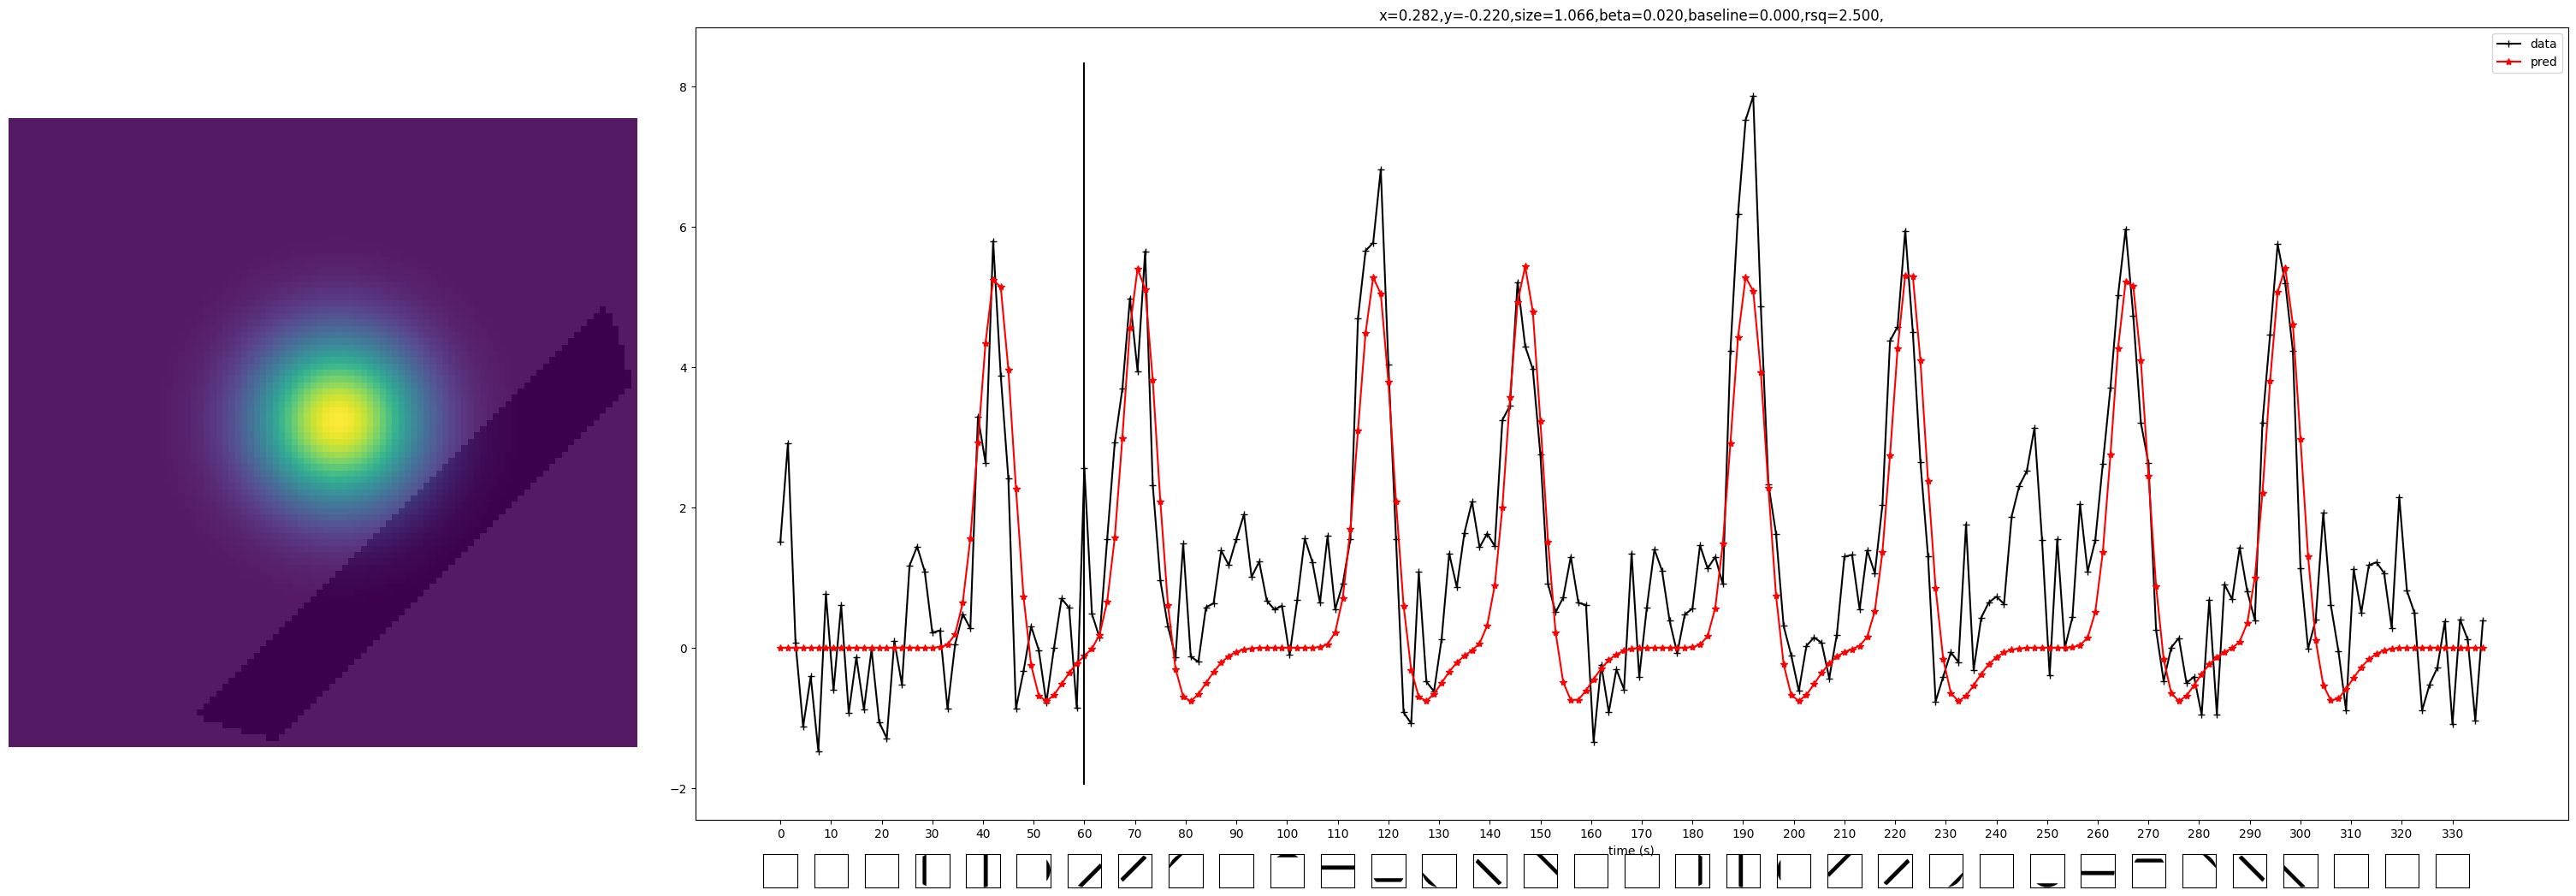

In [ ]:
fig = plt.figure(constrained_layout=True, figsize=(30,10))
subfigs = fig.subfigures(1, 2, width_ratios=[10,30])
i_vx = 99

# ************* TIME COURSE PLOT *************
time_pts = np.arange(data.shape[1]) * TR_s    
ax2 = subfigs[1].add_subplot()
ax2.plot(time_pts, data[i_vx,:], '-+k', label= 'data')
ax2.plot(time_pts, pred_tc[i_vx,:], '-*r', label= 'pred')
ax2.set_xlabel('time (s)')
ax2.legend()

gauss_param_name = ['x', 'y', 'size', 'beta', 'baseline', 'rsq']
title_txt = ''
for i,p in enumerate(gauss_param_name):
    title_txt += f'{p}={prf_params[i_vx,i]:.3f},'
ax2.set_title(title_txt)

# ********* PRF PLOT **********
rf = gauss2D_iso_cart(
    x=prf_stim.x_coordinates,
    y=prf_stim.y_coordinates,
    mu=(prf_params[i_vx,0], prf_params[i_vx,1]),
    sigma=prf_params[i_vx,2])
ax1 = subfigs[0].add_subplot()
ax1.imshow(rf, vmin=0, vmax=1, extent=[-5,5,-5,5])
ax1.axis('off')

time_pt = 40
if time_pt != None:
    ax1.imshow(dm[:,:,time_pt], vmin=0, vmax=1,cmap='Greys', alpha=0.1, extent=[-5,5,-5,5])
    ax_lim = ax2.get_ylim()
    ax2.plot((time_pt*TR_s, time_pt*TR_s), (ax_lim), 'k')


ax2.set_xticks(np.arange(time_pts[0], time_pts[-1],10))
add_dm_to_ts(fig, ax2, dm, TR=1.5, dx_axs=2)    

# Guassian PRF widget
Here is a toy for you to get an intuition for the fitting procedure. Run the cell below, and you will see a plot of a real time series (black) and a red time series (prediction). You can vary the model parameters to try and make the red look as similar as the black as possible. Observe how the PRF shape changes. And how the 

In [32]:
import ipywidgets as widgets
from IPython.display import display, HTML


In [ ]:
widg_model = Iso2DGaussianModel(
    stimulus=prf_stim,                                  # The stimulus we made earlier
    hrf=prf_settings['hrf']['pars'],                        # These are the parameters for the HRF that we normally use at Spinoza (with 7T data). (we can fit it, this will be done later...)
    filter_predictions = prf_settings['filter_predictions'],# Do you want to filter the predictions? (depends what you did to the data, try and match it... default is not to do anything)
    normalize_RFs= prf_settings['normalize_RFs'],           # Normalize the volume of the RF (so that RFs w/ different sizes have the same volume. Generally not needed, as this can be solved using the beta values i.e.,amplitude)
    )

time_pts = np.arange(data.shape[1]) * TR_s    

def g_prf_widget(w_params):
    gauss_param_name = ['x', 'y', 'size', 'beta', 'baseline', 'hrf-deriv', 'hrf-disp']

    i_vx = int(w_params[-1])
    try: 
        print(f'For vx id = {i_vx}, best fit params are...')
        for i,p in enumerate(gauss_param_name):
            print(f'{p}={prf_params[i_vx,i]:.3f},')
    except Exception as e:
        pass


    data_to_plot = data[i_vx,:]
    fig = plt.figure(constrained_layout=True, figsize=(30,10))
    subfigs = fig.subfigures(1, 2, width_ratios=[10,30])

    # ************* TIME COURSE PLOT *************
    
    ax2 = subfigs[1].add_subplot()
    ax2.plot(time_pts, data_to_plot, '-+k', label= 'data')
    w_params = np.array(w_params)
    # w_params = w_params[...,np.newaxis]
    # Create pred tc:
    w_pred = widg_model.return_prediction(
        mu_x = w_params[0], # x position
        mu_y = w_params[1], # y position
        size = w_params[2], # prf size
        beta = w_params[3], # prf amplitude
        baseline = w_params[4], # prf baseline (set to 0)
        hrf_1 = w_params[5],
        hrf_2 = w_params[6],        
    )
    w_pred = np.squeeze(w_pred)
    ax2.plot(time_pts, w_pred, '-*r', label= 'pred')
    ax2.set_xlabel('time (s)')
    ax2.legend()
    ax2.set_xticks(np.arange(time_pts[0], time_pts[-1],10))
    add_dm_to_ts(fig, ax2, dm, TR=1.5, dx_axs=2)

    gauss_param_name = ['x', 'y', 'size', 'beta', 'baseline', 'hrf-deriv', 'hrf-disp']
    title_txt = ''
    for i,p in enumerate(gauss_param_name):
        title_txt += f'{p}={w_params[i]:.3f},'
    rsq = get_rsq(data_to_plot, w_pred)
    title_txt += f'rsq={rsq:.3f}'
    ax2.set_title(title_txt)

    # ********* PRF PLOT **********
    rf = np.flipud(gauss2D_iso_cart(
        x=prf_stim.x_coordinates,
        y=prf_stim.y_coordinates,
        mu=(w_params[0], w_params[1]),
        sigma=w_params[2]))
    ax1 = subfigs[0].add_subplot()
    ax1.imshow(rf, vmin=0, vmax=1, extent=[-5,5,-5,5])
    # ax1.axis('off')
    
    # SHOW
    plt.show()

In [34]:
# ***************** WIDGETS & PARAMETERS VALUES *****************
# Starting params to show the "cartoon" model with dip in the centre

w_params = np.array((
    0,      #mu_x
    0,      #mu_y
    1,      #size
    .1,     #beta
    0,      #baseline
    1,      #hrf_1
    0,      #hrf_2
    0,    #i_vx
))

w_param_title = np.array([
    'mu_x',
    'mu_y',
    'size',
    'beta',
    'baseline',
    'hrf_1',
    'hrf_2',
    'i_vx',
])

w_param_min_max_step = np.array([
    [-6,6,.1],  #mu_x
    [-6,6,.1],  #mu_y
    [0,10,.1], #size
    [0,10,.01], #beta
    [-2,2,.1],  #baseline
    [0,10,.1],  #hrf_1
    [0,10,.1],   #hrf_2
    [0,100,1],  # i_vx    
])

widg_controls=[]
for i in range(len(w_params)):    
    sl=widgets.BoundedFloatText(description=w_param_title[i],
                           min=w_param_min_max_step[i,0], 
                           max=w_param_min_max_step[i,1], 
                           step=w_param_min_max_step[i,2], 
                           value=w_params[i],
                           orientation = "vertical",
                           continuous_update=False)    
    widg_controls.append(sl)
    
widg_Dict = {} 
for c in widg_controls:
    widg_Dict[c.description] = c  

left_widg = widgets.VBox(tuple([widg_controls[i] for i in range(4)]))
right_widg = widgets.VBox([widg_controls[i] for i in range(4,8)])
widg_uif = widgets.HBox([left_widg, right_widg])

def widg_update_N(**xvalor):
    xvalor=[]
    for i in range(len(widg_controls)):
        xvalor.append(widg_controls[i].value)
    
    g_prf_widget(xvalor)

widg_outf = widgets.interactive_output(widg_update_N,widg_Dict)
display(widg_uif, widg_outf)

Output()

# Normalization stage

In [ ]:
gg_ext = Norm_Iso2DGaussianModel(
    stimulus=prf_stim,                                  
    hrf=prf_settings['hrf']['pars'],                    
    normalize_RFs=prf_settings['normalize_RFs'],        
    )        
# The extra bounds we need for the grid fit stage
# i.e., the bounds for the surround amplitude and size
ext_grid_bounds = [
    prf_settings['prf_ampl'],
    prf_settings['norm']['surround_baseline_bound']
]
# The grids on the extra parameters we want to fit
ext_grids = [
    np.array(prf_settings['norm']['surround_amplitude_grid'], dtype='float32'),
    np.array(prf_settings['norm']['surround_size_grid'], dtype='float32'),
    np.array(prf_settings['norm']['neural_baseline_grid'], dtype='float32'),
    np.array(prf_settings['norm']['surround_baseline_grid'], dtype='float32'),            
]


gf_ext = Norm_Iso2DGaussianFitter(
    data=data,           
    model=gg_ext,                  
    n_jobs=prf_settings['n_jobs'],
    previous_gaussian_fitter = gf,
    use_previous_gaussian_fitter_hrf = True,  # Use the previous HRF that has been fit...
    )

gf_ext.grid_fit(
    *ext_grids,
    verbose=True,
    n_batches=prf_settings['n_jobs'],
    rsq_threshold=prf_settings['rsq_threshold'],
    fixed_grid_baseline=prf_settings['fixed_grid_baseline'],
    grid_bounds=ext_grid_bounds,
)



Using HRF from previous gaussian iterative fit
Each batch contains approx. 25 voxels.


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed:    3.1s
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:    3.1s remaining:    3.1s
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:    3.2s finished


### Norm iter fits

In [ ]:
ext_custom_bounds = [
    (prf_settings['prf_ampl']),                             # surround amplitude
    (1e-1, max_eccentricity*6),                             # surround size
    (prf_settings['norm']['neural_baseline_bound']),        # neural baseline (b) 
    (prf_settings['norm']['surround_baseline_bound']),      # surround baseline (d)
] 
# Combine the bounds 
# first create the standard bounds
standard_bounds = [
    (-1.5*max_eccentricity, 1.5*max_eccentricity),          # x bound
    (-1.5*max_eccentricity, 1.5*max_eccentricity),          # y bound
    (1e-1, max_eccentricity*3),                             # prf size bounds
    (prf_settings['prf_ampl']),                             # prf amplitude
    (prf_settings['bold_bsl']),                             # bold baseline (fixed)
]    
# & the hrf bounds. these will be overwritten later by the vx wise hrf parameters
# ( inherited from previous fits)
hrf_bounds = [
    (prf_settings['hrf']['deriv_bound']),                   # hrf_1 bound
    (prf_settings['hrf']['disp_bound']),                    # hrf_2 bound
]
ext_bounds = standard_bounds.copy() + ext_custom_bounds.copy() + hrf_bounds.copy()



In [ ]:
gg_ext = Norm_Iso2DGaussianModel(
    stimulus=prf_stim,                                  
    hrf=prf_settings['hrf']['pars'],                    
    normalize_RFs=prf_settings['normalize_RFs'],        
    )     

# Hand specified minimization method
gf_ext.iterative_fit(
    rsq_threshold=prf_settings['rsq_threshold'], 
    bounds=ext_bounds,
    verbose=False,
    )              
gf_ext.iterative_search_params = filter_for_nans(gf_ext.iterative_search_params)
